PROGETTO 2

Il dataset Linnerud presenta un problema di regressione Multi-Target (3 target totali: Weight, Waist, Pulse).
Addestrare e confrontare alcuni modelli di regressione sul dataset, riducendo il
problema da Multi-Target a Single-Target tramite

1. PCA
2. selezione manuale di un singolo target

1 Data Exploration & Preprocessing
    • Caricamento e Analisi del dataset e fornire un’analisi descrittiva iniziale (i.e. df.describe())
    • Standardization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

2 Target Engineering
    Trasformare il problema Multi-Target in due distinti problemi Single-Target da confrontare:
        • PCA (Target Composto)
            – Applicare la PCA alla matrice dei target standardizzata e mantenere PC1
        • Manuale (Target Selezionato)
            – Selezionare il target Waist dalla matrice dei target standardizzata come singolo target rappresentativo 1

3 Addestramento & Valutazione
    Addestrare i tre modelli di regressione (Linear Regression, Ridge, Lasso) su entrambi gli scenari di target ridotto con PCA e selezione manuale, utilizzando il set di feature completo e standardizzato:
        • Definire e inizializzare i tre modelli di regressione (Lineare, Ridge con α = 1.0, Lasso con α = 0.1)
        • Eseguire l’addestramento su tutto il dataset per entrambi gli scenari
        • Valutare e memorizzare i risultati come Mean Squared Error e R2 Score per ogni combinazione di modello e scenario

4 Analisi & Visualizzazione
    • Applicare la PCA al set di feature standardizzato e mantenere le due componenti principali PC1 e PC2 per la visualizzazione 2D
    • Creare un grafico di dispersione in cui:
        – L’asse X `e il PC1 delle Feature
        – L’asse Y `e la PCA con n components=1
        – Tracciare le tre rette di regressione (Lineare, Ridge, Lasso) ri-addestrate sulla sola PC1 delle Feature, includendo il loro rispettivo R2 Score finale nell’etichetta

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.datasets import load_linnerud
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

1 Data Exploration & Preprocessing
    • Caricamento e Analisi del dataset e fornire un’analisi descrittiva iniziale (i.e. df.describe())
    • Standardization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

In [37]:
data=load_linnerud()
#print(data.DESCR)
print(data.feature_names)


['Chins', 'Situps', 'Jumps']


In [39]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=data.target_names)
print(X.shape)   
print(X.describe)

(20, 3)
<bound method NDFrame.describe of     Chins  Situps  Jumps
0     5.0   162.0   60.0
1     2.0   110.0   60.0
2    12.0   101.0  101.0
3    12.0   105.0   37.0
4    13.0   155.0   58.0
5     4.0   101.0   42.0
6     8.0   101.0   38.0
7     6.0   125.0   40.0
8    15.0   200.0   40.0
9    17.0   251.0  250.0
10   17.0   120.0   38.0
11   13.0   210.0  115.0
12   14.0   215.0  105.0
13    1.0    50.0   50.0
14    6.0    70.0   31.0
15   12.0   210.0  120.0
16    4.0    60.0   25.0
17   11.0   230.0   80.0
18   15.0   225.0   73.0
19    2.0   110.0   43.0>


esploro i dati 

In [40]:
#print(df.dtypes)
print(df.shape)
print(df.nunique())
print(df.corr())

(20, 3)
Chins     12
Situps    16
Jumps     17
dtype: int64
           Chins    Situps     Jumps
Chins   1.000000  0.695727  0.495760
Situps  0.695727  1.000000  0.669206
Jumps   0.495760  0.669206  1.000000


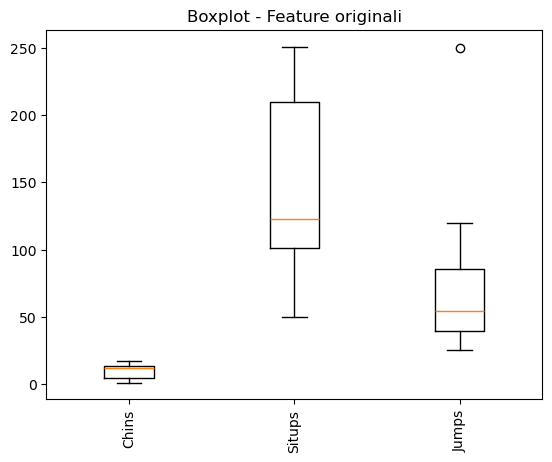

In [41]:
plt.boxplot(X)
plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature originali")
plt.show()

Necessaria standarizzazione, dati troppo diversi tra loro

• Standardization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

In [42]:
scaler=StandardScaler()
X_std=scaler.fit_transform(X)

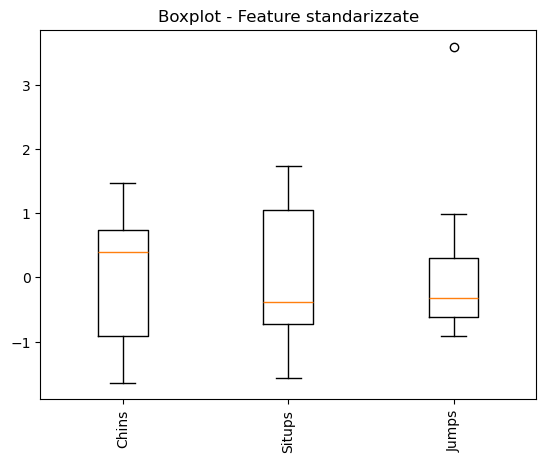

In [43]:
plt.boxplot(X_std)
plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature standarizzate")
plt.show()

2 Target Engineering
    Trasformare il problema Multi-Target in due distinti problemi Single-Target da confrontare:
        • PCA (Target Composto)
            – Applicare la PCA alla matrice dei target standardizzata e mantenere PC1
        • Manuale (Target Selezionato)
            – Selezionare il target Waist dalla matrice dei target standardizzata come singolo target rappresentativo 1


        • PCA (Target Composto)
            – Applicare la PCA alla matrice dei target standardizzata e mantenere PC1

In [44]:
#Standarizzo le y
scaler=StandardScaler()
y_std=scaler.fit_transform(y)

#dopo aver applicato la standarizzazione delle feature, posso applicare la PCA per una riduzione dimensionale
pca=PCA() #non ho definito n_components, quindi PCA calcola tante componenti quante sono le feature 
pca.fit(y_std) #trova PC1, PC2, PC3, PC4, ecc con PC1 e PC2 con massima varianza

exp_var=pca.explained_variance_ratio_  #contiene quanta varianza del dataset spiega ogni componente PC
cum_var=np.cumsum(exp_var) #somma cumulativa
print(f" varianza: {exp_var}")
print(f" varianza cumulativa: {cum_var}")

#mantengo solo PC1
pca=PCA(n_components=1) #definisco n_components=1
y_pca=pca.fit_transform(y_std)
#print(y_pca)

 varianza: [0.70137682 0.25540925 0.04321393]
 varianza cumulativa: [0.70137682 0.95678607 1.        ]


        • Manuale (Target Selezionato)
            – Selezionare il target Waist dalla matrice dei target standardizzata come singolo target rappresentativo 1

In [45]:
print(data.target_names)
y_sel=y_std[:,1]

['Weight', 'Waist', 'Pulse']


3 Addestramento & Valutazione
    Addestrare i tre modelli di regressione (Linear Regression, Ridge, Lasso) su entrambi gli scenari di target ridotto con PCA e selezione manuale, utilizzando il set di feature completo e standardizzato:
        • Definire e inizializzare i tre modelli di regressione (Lineare, Ridge con α = 1.0, Lasso con α = 0.1)
        • Eseguire l’addestramento su tutto il dataset per entrambi gli scenari
        • Valutare e memorizzare i risultati come Mean Squared Error e R2 Score per ogni combinazione di modello e scenario

In [55]:
models={
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}
risultati=[]
for tipo_dati, y_target in [("PCA", y_pca.ravel()), ("Manual", y_sel)]:
    #print(f"\n=== Dati: {tipo_dati} ===")
    for name, model in models.items():
        model.fit(X_std, y_target)
        y_pred = model.predict(X_std)


        mse = mean_squared_error(y_target, y_pred)
        r2 = r2_score(y_target, y_pred)

        risultati.append([tipo_dati, name, round(mse,4), round(r2,4)])
        #print(f"{name} -> MSE: {mse:.4f} | R²: {r2:.4f}")

        for f, val in zip(data.feature_names, model.coef_):
            print(f"{f}: {val}")
df_risultato=pd.DataFrame(risultati,columns=["Target","Model","MSE","R2"])
for r in risultati:
    print(r)

Chins: -0.2106324063233317
Situps: -1.0128108677137238
Jumps: 0.4991848860650076
Chins: -0.24179375244128035
Situps: -0.8870958857610264
Jumps: 0.41000400993631797
Chins: -0.13375697180795731
Situps: -0.7611941618220361
Jumps: 0.19268967744499593
Chins: -0.22596508169110172
Situps: -0.7881778997807418
Jumps: 0.4479785615041866
Chins: -0.24448098848462238
Situps: -0.6907965005000736
Jumps: 0.37332360606386644
Chins: -0.14908428621521136
Situps: -0.5365609285835251
Jumps: 0.1414805175893475
['PCA', 'Linear', 1.2689, 0.397]
['PCA', 'Ridge', 1.2759, 0.3936]
['PCA', 'Lasso', 1.3324, 0.3668]
['Manual', 'Linear', 0.4522, 0.5478]
['Manual', 'Ridge', 0.4567, 0.5433]
['Manual', 'Lasso', 0.5157, 0.4843]


MSE errore quadratico medio (più è basso meglio è).
Nel mio caso il target manuale (Waist) produce risultati migliori rispetto al target ottenuto con PCA

R2 quanto il modello spiega i dati (più vicino a 1 meglio è)
in nessun caso ho una situazione perfetta o buona, i valori maggiori (interno allo 0.54) si ottengono con i dati originali e non con la PCA

Riassumento PCA, comprime il target ma peggiora le perfomance
Il target scelto è più interpretabile e migliore della PCA1


RIDGE e LINEAR mostrano prestazioni simili con Ridge leggermente migliore
LASSO le sue prestazioni sono inferiori rispetto ai due precedenti descritti

Dataset veramente piccolo (20 righe) quindi PCA porta ad una perdita di informazione importante

4 Analisi & Visualizzazione
    • Applicare la PCA al set di feature standardizzato e mantenere le due componenti principali PC1 e PC2 per la visualizzazione 2D
    • Creare un grafico di dispersione in cui:
        – L’asse X `e il PC1 delle Feature
        – L’asse Y `e la PCA con n components=1
        – Tracciare le tre rette di regressione (Lineare, Ridge, Lasso) ri-addestrate sulla sola PC1 delle Feature, includendo il loro rispettivo R2 Score finale nell’etichetta

    • Applicare la PCA al set di feature standardizzato e mantenere le due componenti principali PC1 e PC2 per la visualizzazione 2D

In [146]:
pca=PCA() #non ho definito n_components, quindi PCA calcola tante componenti quante sono le feature 
pca.fit(X_std) #trova PC1, PC2, PC3, PC4, ecc con PC1 e PC2 con massima varianza

exp_var=pca.explained_variance_ratio_  #contiene quanta varianza del dataset spiega ogni componente PC
cum_var=np.cumsum(exp_var) #somma cumulativa
print(f" varianza: {exp_var}")
print(f" varianza cumulativa: {cum_var}")

 varianza: [0.74814431 0.16834322 0.08351247]
 varianza cumulativa: [0.74814431 0.91648753 1.        ]


con 2 PCA ottengo quadi il 91,65%, ottimo

In [61]:
#mantengo solo PC1 e PC2
pca=PCA(n_components=2) #definisco n_components=2
X_pca=pca.fit_transform(X_std)
#print(X_pca)

    • Creare un grafico di dispersione in cui:
        – L’asse X `e il PC1 delle Feature
        – L’asse Y `e la PCA con n components=1
        – Tracciare le tre rette di regressione (Lineare, Ridge, Lasso) ri-addestrate sulla sola PC1 delle Feature, includendo il loro rispettivo R2 Score finale nell’etichetta

C:\Users\uberti\AppData\Local\Temp\ipykernel_9080\3255029355.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


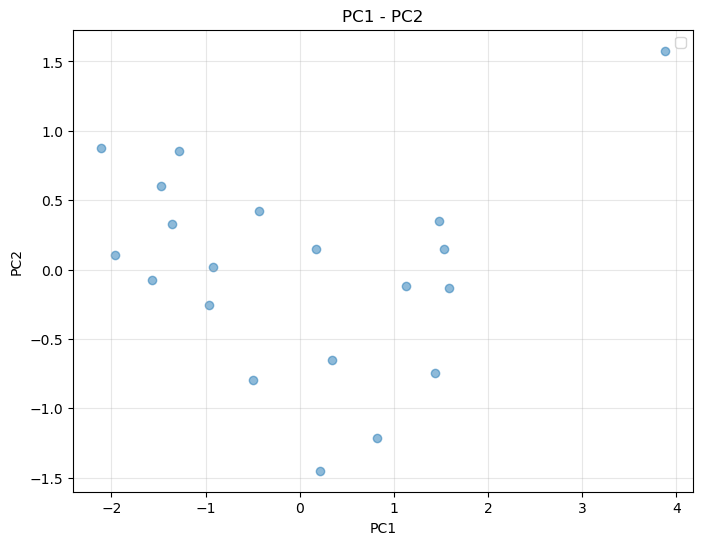

In [62]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
#plt.scatter(df["petal length (cm)"],y_pred,label="Predetti",alpha=0.4, color="red")
plt.title("PC1 - PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

a disposizione solo 20 punti, punti tra loro sparsi, non sembra ci siano gruppi netti. C'è probabilmente un outlier con x=4, forse y=-1.5

In [69]:
#models = {
#    "Linear": LinearRegression(),
#    "Ridge": Ridge(alpha=1.0),
#    "Lasso": Lasso(alpha=0.1)
#}
risultati = {}
X_pc1 = X_pca[:,0].reshape(-1,1)
for name, model in models.items():
    model.fit(X_pc1, y_pca)
    y_pred = model.predict(X_pc1)
    r2 = r2_score(y_pca, y_pred)
    risultati[name] = (model, r2)  
print(risultati)

{'Linear': (LinearRegression(), 0.22852134815045666), 'Ridge': (Ridge(), 0.22841282658556206), 'Lasso': (Lasso(alpha=0.1), 0.2264038613845415)}


In [70]:
#ordino i punti in base a PC1
idx = np.argsort(X_pc1[:,0])
X_sorted = X_pc1[idx]

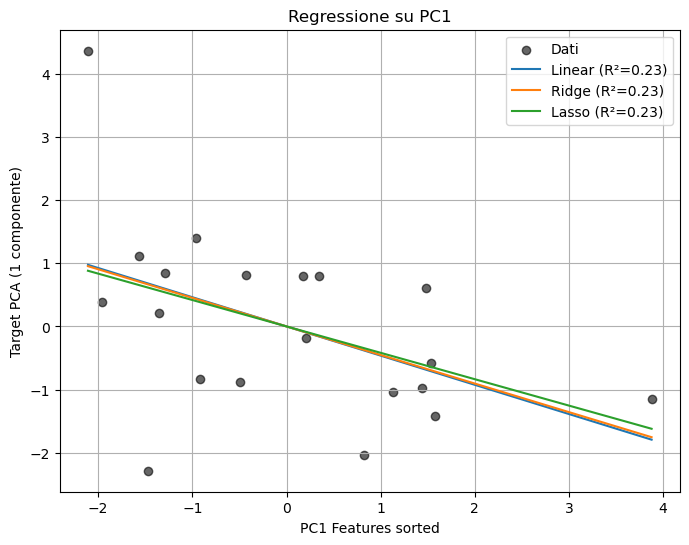

In [71]:
plt.figure(figsize=(8,6))
# scatter reale
plt.scatter(X_pc1[:,0], y_pca, color="black", alpha=0.6, label="Dati")
# linee modelli
for name, (model, r2) in risultati.items():
    y_line = model.predict(X_sorted)
    plt.plot(X_sorted[:,0], y_line, label=f"{name} (R²={r2:.2f})")

plt.xlabel("PC1 Features sorted")
plt.ylabel("Target PCA (1 componente)")
plt.title("Regressione su PC1")

plt.legend()
plt.grid()

plt.show()

Relazione negativa (all'aumentare di PC1 il raget diminuisce).
Relazione debole (r2=0.23). Molti punti non sono sulla retta